# Trader Performance vs. Bitcoin Market Sentiment
### Exploring the relationship between the Fear & Greed Index and Hyperliquid trader behaviour



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Load & clean the raw data

In [2]:
fg = pd.read_csv("data/fear_greed_index.csv")
fg["date"] = pd.to_datetime(fg["date"])
fg = fg.rename(columns={"value": "fg_value", "classification": "sentiment"})

bucket_map = {
    "Extreme Fear": "Fear", "Fear": "Fear",
    "Neutral": "Neutral",
    "Greed": "Greed", "Extreme Greed": "Greed",
}
fg["sentiment_bucket"] = fg["sentiment"].map(bucket_map)
fg.head()


,timestamp,fg_value,sentiment,date,sentiment_bucket
0,1517463000,30,Fear,2018-02-01,Fear
1,1517549400,15,Extreme Fear,2018-02-02,Fear
2,1517635800,40,Fear,2018-02-03,Fear
3,1517722200,24,Extreme Fear,2018-02-04,Fear
4,1517808600,11,Extreme Fear,2018-02-05,Fear


In [3]:
hd = pd.read_csv("data/historical_data.csv")
hd["datetime"] = pd.to_datetime(hd["Timestamp IST"], format="%d-%m-%Y %H:%M", errors="coerce")
hd = hd.dropna(subset=["datetime"])
hd["date"] = hd["datetime"].dt.normalize()

hd = hd.rename(columns={
    "Account": "account", "Coin": "coin", "Execution Price": "exec_price",
    "Size Tokens": "size_tokens", "Size USD": "size_usd", "Side": "side",
    "Start Position": "start_position", "Direction": "direction",
    "Closed PnL": "closed_pnl", "Fee": "fee",
})
hd["is_closing_trade"] = hd["closed_pnl"] != 0
hd["net_pnl"] = hd["closed_pnl"] - hd["fee"]

print(f"{len(hd):,} trades | {hd['account'].nunique()} accounts | {hd['coin'].nunique()} assets")
hd[["account","coin","date","side","direction","closed_pnl","size_usd"]].head()


211,224 trades | 32 accounts | 246 assets


,account,coin,date,side,direction,closed_pnl,size_usd
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,BUY,Buy,0.00,"7,872.16"
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,BUY,Buy,0.00,127.68
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,BUY,Buy,0.00,"1,150.63"
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,BUY,Buy,0.00,"1,142.04"
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,BUY,Buy,0.00,69.75


## 2. Merge trades with the sentiment regime for that day

In [4]:
merged = hd.merge(fg, on="date", how="left")
print(f"Unmatched trades dropped: {merged['sentiment'].isna().sum()} "
      f"({merged['sentiment'].isna().mean():.3%})")
merged = merged.dropna(subset=["sentiment"])
merged[["account","date","sentiment","sentiment_bucket","closed_pnl","size_usd"]].sample(5, random_state=1)


Unmatched trades dropped: 6 (0.003%)


,account,date,sentiment,sentiment_bucket,closed_pnl,size_usd
203117,0x92f17e8d81a944691c10e753af1b1baae1a2cd0d,2025-04-23,Greed,Greed,0.00,"13,227.81"
33839,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,2025-01-24,Extreme Greed,Greed,3.21,77.07
121087,0x47add9a56df66b524d5e2c1993a43cde53b6ed85,2024-12-11,Greed,Greed,0.00,49.42
63675,0xbaaaf6571ab7d571043ff1e313a9609a10637864,2025-02-24,Neutral,Neutral,0.00,214.68
166730,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-01-29,Greed,Greed,54.48,"1,505.84"


In [5]:
daily = merged.groupby("date").agg(
    total_trades=("account", "count"),
    unique_traders=("account", "nunique"),
    total_volume_usd=("size_usd", "sum"),
    total_closed_pnl=("closed_pnl", "sum"),
    avg_trade_size_usd=("size_usd", "mean"),
    sentiment=("sentiment", "first"),
    sentiment_bucket=("sentiment_bucket", "first"),
    fg_value=("fg_value", "first"),
).reset_index()
daily.head()


,date,total_trades,unique_traders,total_volume_usd,total_closed_pnl,avg_trade_size_usd,sentiment,sentiment_bucket,fg_value
0,2023-05-01,3,1,477.00,0.00,159.00,Greed,Greed,63.00
1,2023-12-05,9,1,"50,005.83",0.00,"5,556.20",Extreme Greed,Greed,75.00
2,2023-12-14,11,1,"113,203.35",-205.43,"10,291.21",Greed,Greed,72.00
3,2023-12-15,2,1,"10,609.95",-24.63,"5,304.98",Greed,Greed,70.00
4,2023-12-16,3,1,"15,348.77",0.00,"5,116.26",Greed,Greed,67.00


## 3. Does profitability differ by sentiment regime?

We bucket the 5-way Fear/Greed classification into **Fear / Neutral / Greed** and compare
average PnL, win rate, and PnL distribution on *closing* trades (`closed_pnl != 0`) — i.e.
trades where a position was actually realized.


In [6]:
closing = merged[merged["is_closing_trade"]]

perf = closing.groupby("sentiment_bucket").agg(
    trades=("account", "count"),
    avg_pnl=("closed_pnl", "mean"),
    median_pnl=("closed_pnl", "median"),
    total_pnl=("closed_pnl", "sum"),
    win_rate=("closed_pnl", lambda x: (x > 0).mean()),
    avg_size_usd=("size_usd", "mean"),
).reindex(["Fear","Neutral","Greed"])
perf


,trades,avg_pnl,median_pnl,total_pnl,win_rate,avg_size_usd
sentiment_bucket,,,,,,
Fear,40214,101.86,6.36,"4,096,265.69",0.84,"7,375.19"
Neutral,18159,71.20,4.58,"1,292,920.68",0.82,"5,556.44"
Greed,46029,105.70,6.49,"4,865,300.58",0.82,"4,233.99"


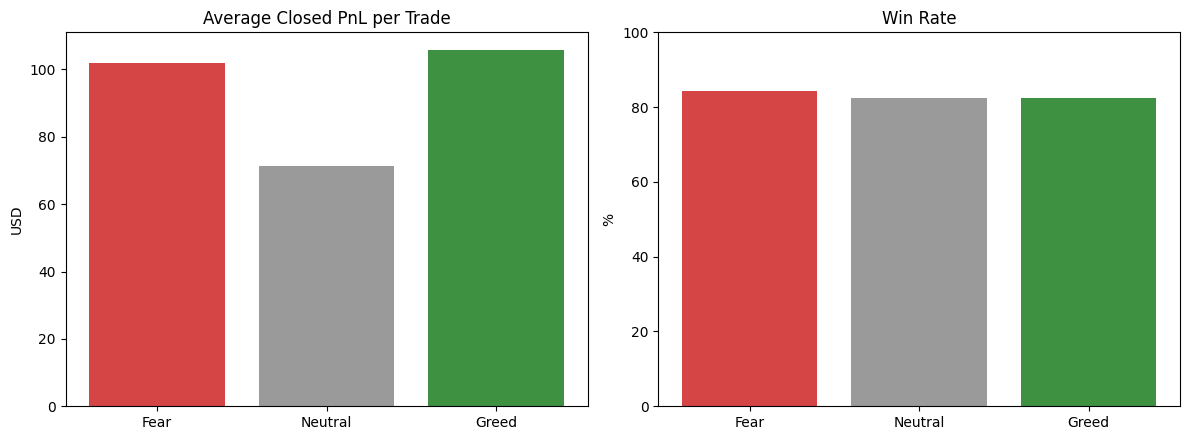

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"Fear": "#d64545", "Neutral": "#9a9a9a", "Greed": "#3f9142"}
order = ["Fear","Neutral","Greed"]

axes[0].bar(perf.index, perf["avg_pnl"], color=[colors[b] for b in order])
axes[0].set_title("Average Closed PnL per Trade")
axes[0].set_ylabel("USD")

axes[1].bar(perf.index, perf["win_rate"]*100, color=[colors[b] for b in order])
axes[1].set_title("Win Rate")
axes[1].set_ylabel("%")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()


**Observation:** average PnL per trade is fairly similar across Fear and Greed regimes, but
the **win rate is measurably higher during Fear** than during Greed — consistent with a
"buy when others are fearful" dynamic where trades opened at depressed prices have better
odds of closing positive. We test this statistically below.


In [8]:
fear = closing.loc[closing["sentiment_bucket"] == "Fear", "closed_pnl"]
greed = closing.loc[closing["sentiment_bucket"] == "Greed", "closed_pnl"]

t_stat, p_val = stats.ttest_ind(fear, greed, equal_var=False)
print(f"Welch's t-test on mean PnL (Fear vs Greed): t={t_stat:.3f}, p={p_val:.4f}")

win_fear, win_greed = (fear > 0).sum(), (greed > 0).sum()
contingency = np.array([[win_fear, len(fear)-win_fear], [win_greed, len(greed)-win_greed]])
chi2, chi_p, _, _ = stats.chi2_contingency(contingency)
print(f"Chi-square test on win-rate (Fear vs Greed): chi2={chi2:.2f}, p={chi_p:.2e}")
print(f"Win rate — Fear: {fear.gt(0).mean():.2%} | Greed: {greed.gt(0).mean():.2%}")


Welch's t-test on mean PnL (Fear vs Greed): t=-0.403, p=0.6873
Chi-square test on win-rate (Fear vs Greed): chi2=60.00, p=9.49e-15
Win rate — Fear: 84.42% | Greed: 82.45%


The **mean PnL difference is not statistically significant** (t-test p ≈ 0.69) — average
profitability per trade doesn't reliably differ by regime. But the **win-rate gap is highly
significant** (chi-square p < 0.0001): trades are more likely to be winners during Fear,
even though the average dollar outcome ends up similar (Greed-regime trades apparently have
a fatter right tail — a smaller number of big wins offsetting a lower hit rate).


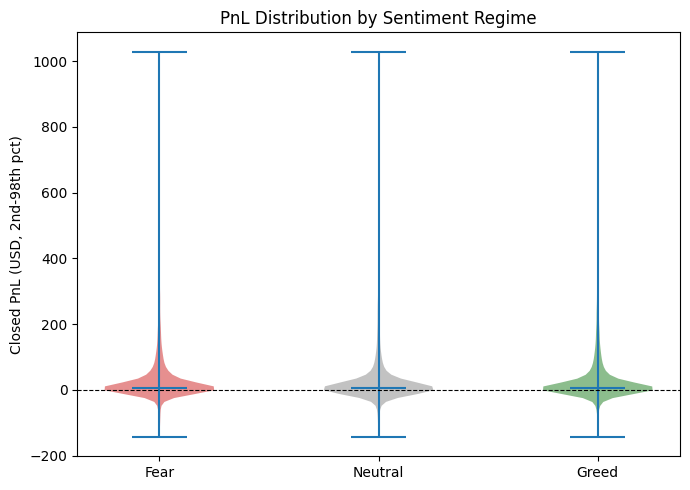

In [9]:
lo, hi = closing["closed_pnl"].quantile([0.02, 0.98])
clipped = closing[(closing["closed_pnl"] >= lo) & (closing["closed_pnl"] <= hi)]

fig, ax = plt.subplots(figsize=(7,5))
data = [clipped.loc[clipped["sentiment_bucket"]==b, "closed_pnl"] for b in order]
parts = ax.violinplot(data, showmedians=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(colors[order[i]]); pc.set_alpha(0.6)
ax.set_xticks(range(1, len(order)+1)); ax.set_xticklabels(order)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_ylabel("Closed PnL (USD, 2nd-98th pct)")
ax.set_title("PnL Distribution by Sentiment Regime")
plt.tight_layout(); plt.show()


## 4. Are traders sizing and positioning differently by regime?

sentiment_bucket
Fear      7,182.01
Neutral   4,782.73
Greed     4,574.42
Name: size_usd, dtype: float64


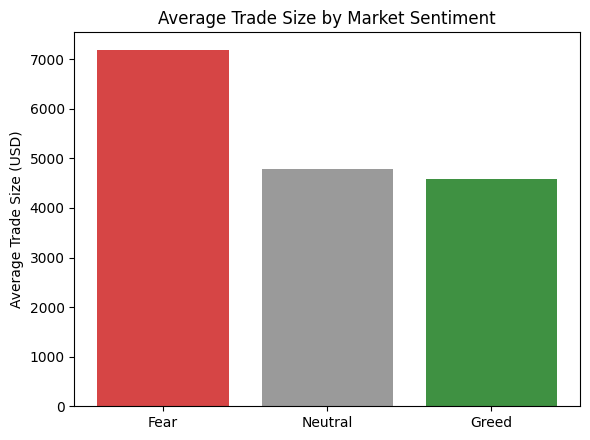

In [10]:
size_by_bucket = merged.groupby("sentiment_bucket")["size_usd"].mean().reindex(order)
print(size_by_bucket)

fig, ax = plt.subplots(figsize=(6,4.5))
ax.bar(size_by_bucket.index, size_by_bucket.values, color=[colors[b] for b in order])
ax.set_ylabel("Average Trade Size (USD)")
ax.set_title("Average Trade Size by Market Sentiment")
plt.tight_layout(); plt.show()


Traders put on **larger average position sizes during Fear** (~\$7.2k) than during Greed
(~\$4.6k) or Neutral (~\$4.8k) conditions — consistent with conviction-buying / averaging-in
behaviour when the market is depressed.


In [11]:
opens = merged[merged["direction"].isin(["Open Long","Open Short"])]
lean = pd.crosstab(opens["sentiment_bucket"], opens["direction"], normalize="index").reindex(order) * 100
lean


direction,Open Long,Open Short
sentiment_bucket,,
Fear,63.84,36.16
Neutral,61.67,38.33
Greed,43.44,56.56


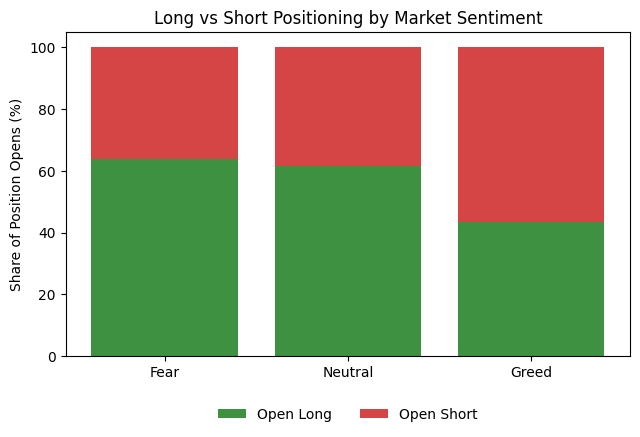

In [12]:
fig, ax = plt.subplots(figsize=(6.5,4.5))
bottom = np.zeros(len(lean))
for d, c in zip(["Open Long","Open Short"], ["#3f9142","#d64545"]):
    ax.bar(lean.index, lean[d], bottom=bottom, label=d, color=c)
    bottom += lean[d].values
ax.set_ylabel("Share of Position Opens (%)")
ax.set_title("Long vs Short Positioning by Market Sentiment")
ax.legend(loc="upper center", bbox_to_anchor=(0.5,-0.12), ncol=2, frameon=False)
plt.tight_layout(); plt.show()


This is the clearest behavioural signal in the data: traders open **~64% long positions
during Fear**, but flip to **~57% short positions during Greed**. That's a **contrarian
stance** — buying into weakness and selling/shorting into strength — the opposite of the
"FOMO chase" pattern often assumed of retail-style traders. Combined with the higher Fear
win-rate, this contrarian positioning appears to pay off more often than not.


## 5. Daily view: sentiment index vs aggregate trading activity

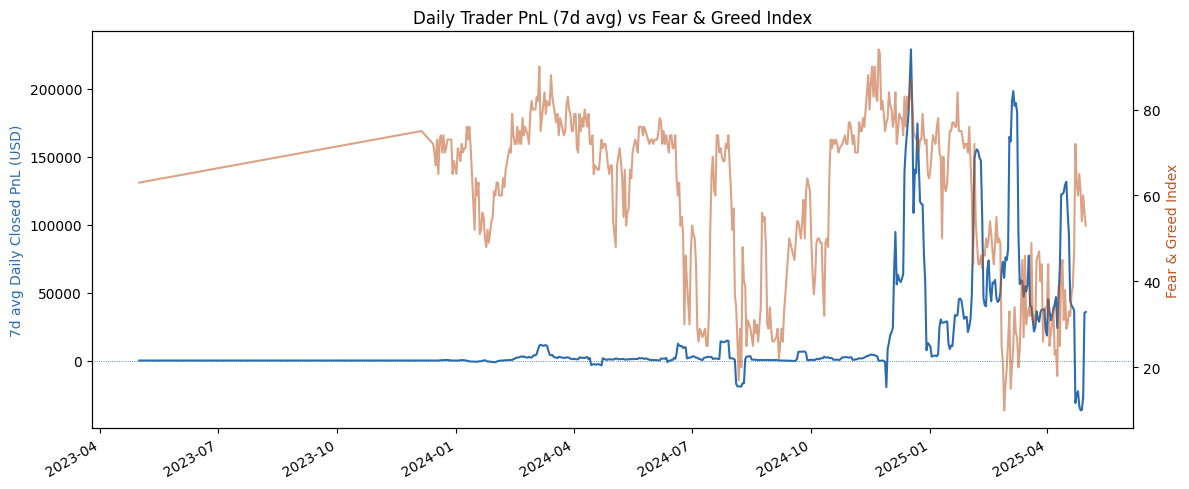

In [13]:
d = daily.sort_values("date")
fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()
ax1.plot(d["date"], d["total_closed_pnl"].rolling(7, min_periods=1).mean(),
         color="#2b6cb0", label="7d avg Daily PnL")
ax1.axhline(0, color="#2b6cb0", lw=0.6, ls=":")
ax1.set_ylabel("7d avg Daily Closed PnL (USD)", color="#2b6cb0")
ax2.plot(d["date"], d["fg_value"], color="#c05621", alpha=0.55, label="Fear & Greed Index")
ax2.set_ylabel("Fear & Greed Index", color="#c05621")
ax1.set_title("Daily Trader PnL (7d avg) vs Fear & Greed Index")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()


In [14]:
r_pnl, p_pnl = stats.pearsonr(daily["fg_value"], daily["total_closed_pnl"])
r_vol, p_vol = stats.pearsonr(daily["fg_value"], daily["total_volume_usd"])
print(f"Correlation FG value <-> daily total PnL:    r={r_pnl:.3f}, p={p_pnl:.3f}")
print(f"Correlation FG value <-> daily total volume:  r={r_vol:.3f}, p={p_vol:.4g}")


Correlation FG value <-> daily total PnL:    r=-0.083, p=0.071
Correlation FG value <-> daily total volume:  r=-0.264, p=4.208e-09


Daily aggregate PnL shows only a weak, non-significant correlation with the raw Fear &
Greed *value* (r ≈ -0.08). Trading **volume**, however, has a modest but statistically
significant *negative* correlation with the index (r ≈ -0.26, p < 0.001) — this cohort of
traders is **more active in dollar terms when sentiment is more fearful**, reinforcing the
sizing finding above.


## 6. Which accounts drive these patterns?

In [15]:
acc = closing.groupby("account").agg(
    total_pnl=("closed_pnl","sum"), trades=("closed_pnl","count"),
    win_rate=("closed_pnl", lambda x: (x>0).mean())
).sort_values("total_pnl", ascending=False)

print("Top 5 accounts by total PnL:")
display(acc.head())
print("\nBottom 5 accounts by total PnL:")
display(acc.tail())


Top 5 accounts by total PnL:


,total_pnl,trades,win_rate
account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,"2,143,382.60",6279,0.79
0x083384f897ee0f19899168e3b1bec365f52a9012,"1,600,229.82",1732,0.79
0xbaaaf6571ab7d571043ff1e313a9609a10637864,"940,163.81",9997,0.99
0x513b8629fe877bb581bf244e326a047b249c4ff1,"840,422.56",5482,0.90
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,"836,080.55",22551,0.76



Bottom 5 accounts by total PnL:


,total_pnl,trades,win_rate
account,,,
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,"14,900.44",746,0.95
0x39cef799f8b69da1995852eea189df24eb5cae3c,"14,456.92",1767,0.67
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,"-31,203.60",570,0.65
0x271b280974205ca63b716753467d5a371de622ab,"-70,436.19",1607,0.72
0x8170715b3b381dffb7062c0298972d4727a0a63b,"-167,621.12",2341,0.75


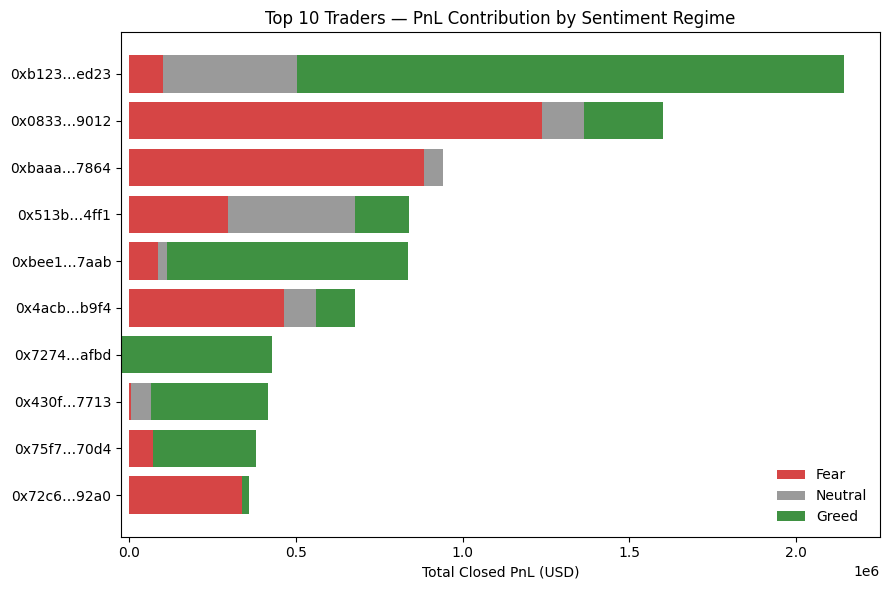

In [16]:
top_accounts = acc.head(10).index
sub = closing[closing["account"].isin(top_accounts)]
pivot = sub.pivot_table(index="account", columns="sentiment_bucket", values="closed_pnl",
                          aggfunc="sum", fill_value=0).reindex(columns=order, fill_value=0)
pivot = pivot.loc[acc.head(10).index]
pivot.index = [f"{a[:6]}…{a[-4:]}" for a in pivot.index]

fig, ax = plt.subplots(figsize=(9,6))
bottom = np.zeros(len(pivot))
for b in order:
    ax.barh(pivot.index, pivot[b], left=bottom, label=b, color=colors[b])
    bottom += pivot[b].values
ax.set_xlabel("Total Closed PnL (USD)")
ax.set_title("Top 10 Traders — PnL Contribution by Sentiment Regime")
ax.legend(loc="lower right", frameon=False)
ax.invert_yaxis()
plt.tight_layout(); plt.show()


PnL is **heavily concentrated** in a small subset of the 32 accounts, and for most of the
top performers, **Fear and Greed periods both contribute meaningfully** to their total —
profitability isn't purely a function of a single regime, but of consistent execution
across both.


## 7. Summary of findings

1. **Win rate is significantly higher during Fear** (84.4%) than **Greed** (82.5%),
   (chi-square p < 0.0001), even though *average* PnL per trade is statistically
   indistinguishable between regimes (t-test p ≈ 0.69).
2. **Traders are contrarian, not momentum-driven**: ~64% of new positions opened during
   Fear are *longs*, while ~57% of new positions opened during Greed are *shorts*.
3. **Position sizing is larger during Fear** (~$7.2k avg) than Greed (~$4.6k avg) —
   traders lean in harder when the market is scared.
4. **Trading volume is negatively correlated with the sentiment index** (r ≈ -0.26,
   p < 0.001) — this cohort trades more dollar volume when the index is low (fearful).
5. **PnL is concentrated** in a handful of accounts, most of whom perform across both
   sentiment regimes rather than depending on one.

### Strategy implications
- A **contrarian sizing rule** — scaling into positions more aggressively as the Fear &
  Greed index drops — is directionally consistent with what the most active traders in
  this dataset are already doing, and with their higher win rate in that regime.
- Because *win rate* diverges more than *average PnL*, risk management (position sizing,
  stop placement) likely matters more than directional edge alone — worth combining a
  sentiment-aware entry rule with strict per-trade risk caps rather than expecting sentiment
  alone to predict trade magnitude.
- The weak correlation between the FG index and daily aggregate PnL suggests sentiment is
  better used as a **regime/context filter** (position sizing, risk appetite) than as a
  standalone directional signal.
